I. Import 

In [ ]:
import pandas as pd
import numpy as np
from matplotlib import pyplot as plt
import sys, os
from pathlib import Path

folders = ["Data", "Strategy", "Engine", "Analytics", "Risk"]
base = Path.cwd().parent          # Main/ -> Backtester/

for folder in folders:
    sys.path.append(str(base / folder))


II. Load Data

In [ ]:
from data_load import getData

df, tickerList, p, years = getData()
start_balance = int(p["Value"].iat[7])


[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed


In [ ]:
rf = float(p["Value"].iat[8])
slow_ma = int(p["Value"].iat[9])
fast_ma = int(p["Value"].iat[10])
upper_me = float(p["Value"].iat[11])
lower_me = float(p["Value"].iat[12])
equal_me = float(p["Value"].iat[13])
stop_me = float(p["Value"].iat[14])
upper_pt = float(p["Value"].iat[15])
lower_pt = float(p["Value"].iat[16])
equal_pt = float(p["Value"].iat[17])
stop_pt = float(p["Value"].iat[18])
commission = float(p["Value"].iat[19])
refit = int(p["Value"].iat[20])
window = int(p["Value"].iat[21])
window_garch = int(p["Value"].iat[22])
cap = float(p["Value"].iat[23])
band = float(p["Value"].iat[24])
vol_model = p["Value"].iat[25]
if (vol_model == "weighted_std"): lambDa = float(p["Value"].iat[26])
target_vol = float(p["Value"].iat[27])

In [ ]:
  #weight dict
tickers = tickerList["ticker"]
weight_dict = {}
for ticker in tickers:
    weight_dict[ticker] = tickerList.loc[tickerList["ticker"] == ticker, "weight"]

#close price data aggregate table
price = pd.DataFrame({})
for ticker in tickers:
    price[ticker] = df[ticker]["Close"]

priceo = pd.DataFrame({})
for ticker in tickers:
    priceo[ticker] = df[ticker]["Open"]

#initial balance dict
tickerList["start_balance"] = start_balance*tickerList["weight"]
ib = {}
for ticker in tickers:
    ib[ticker] = tickerList.loc[tickerList["ticker"] == ticker, "start_balance"]

#strategy dict
strategy_dict = {
    "MA": [],
    "ME": [],
    "PT": []
}
for ticker in tickers:
    strat = tickerList.loc[tickerList["ticker"] == ticker, "strategy"].item()
    strategy_dict[strat].append(ticker)

price = price.dropna()

III. Bench return

In [ ]:
#bench return of each ticker if held from start to end
for ticker in tickers:
    df[ticker]["return"] = df[ticker]["Close"].pct_change() + 1
    df[ticker]["return"].iat[0] = 1

for ticker in tickers:
    sb = tickerList.loc[tickerList["ticker"] == ticker, "start_balance"].item()
    df[ticker]["bench_balance"] = sb*df[ticker]["return"].cumprod()

#bench return dict
bench_return_dict = {}
for ticker in tickers:
    sb = tickerList.loc[tickerList["ticker"] == ticker, "start_balance"].item()
    bench_return_dict[ticker] = round(float((df[ticker]["bench_balance"].iat[-1]) / sb) - 1,4)

# %bench return of each ticker and portfolio
port_bench_return = 0
for ticker in tickers:
    print(ticker, "bench return: ", round(bench_return_dict[ticker]*100,2), "%")
    weight = weight_dict[ticker].item()
    port_bench_return += bench_return_dict[ticker]*weight

print("portfolio bench return: ", round(port_bench_return*100, 2), "%")

TSLA bench return:  476.45 %
AAPL bench return:  217.29 %
AMZN bench return:  41.29 %
XLU bench return:  58.55 %
XLF bench return:  35.75 %
KO bench return:  63.76 %
PEP bench return:  77.05 %
portfolio bench return:  163.22 %


In [ ]:
bench_return_table = pd.DataFrame({})

for ticker in (strategy_dict["MA"] + strategy_dict["ME"]):
    bench_return_table[ticker] = round(df[ticker]["bench_balance"], 2)

for i in range(0, len(strategy_dict["PT"]), 2):
    ticker1 = strategy_dict["PT"][i]
    ticker2 = strategy_dict["PT"][i + 1]
    bench_return_table[f"pair({ticker1}, {ticker2})"] = round(df[ticker1]["bench_balance"] + df[ticker2]["bench_balance"], 2)


cols = bench_return_table.columns.copy()
cols = list(cols)

bench_return_table["Portfolio"] = 0
for col in cols:
    bench_return_table["Portfolio"] += bench_return_table[col]


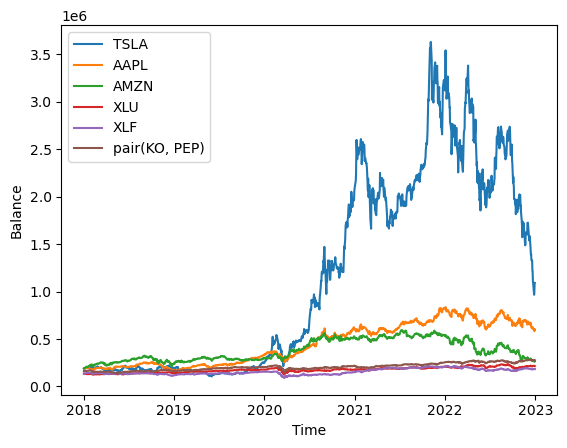

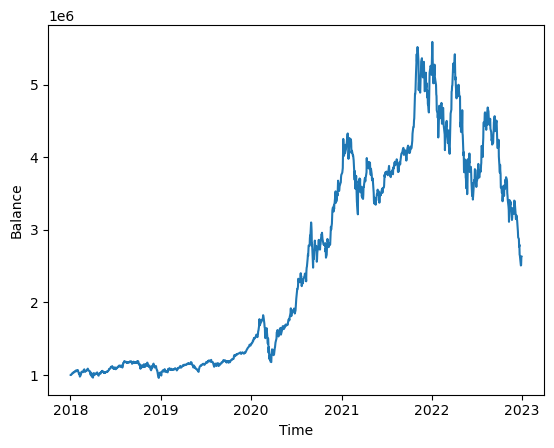

In [ ]:
plt.xlabel("Time")
plt.ylabel("Balance")
for col in cols:
    plt.plot(bench_return_table[col], label = col)
plt.legend()
plt.show()

plt.plot(bench_return_table["Portfolio"])
plt.xlabel("Time")
plt.ylabel("Balance")
plt.show()


In [ ]:
#Metrics for the portfolio
from maximum_drawdown import maximumDrawdown
from ret import returnRate
from sharpe_ratio import sharpeRatio

sr = sharpeRatio(bench_return_table["Portfolio"], rf)

annual_return, ret_temp = returnRate(bench_return_table["Portfolio"])

md, mdd = maximumDrawdown(bench_return_table["Portfolio"])

print(
    "Return: ", ret_temp*100, "%"
    "\nAnnual Return: ", annual_return*100, "%"
    "\nSharpe Ratio: ", sr,
    "\nMaximum Drawdown: ", md*100, "%"
    "\nMaximum Drawdown Duration: ", mdd
)

Return:  163.22062136779377 %
Annual Return:  21.398647757192755 %
Sharpe Ratio:  0.61343 
Maximum Drawdown:  -55.11060114600323 %
Maximum Drawdown Duration:  250


IV Get Order 

In [ ]:
from moving_average import maTrendFollowing
from mean_reversion import meanReversion
from pair_trading import pairTrading

#moving average
temp_ma = maTrendFollowing(price, strategy_dict["MA"], slow_ma, fast_ma)

#mean reversion
temp_me = meanReversion(price, strategy_dict["ME"],  upper_me, lower_me, equal_me, stop_me)

#pair trade
temp_pt = []
length = len(strategy_dict["PT"])
for i in range(0, length, 2):
    pair = pairTrading(price, strategy_dict["PT"][i], strategy_dict["PT"][i + 1], 252,  upper_pt, lower_pt, equal_pt, stop_pt)
    temp_pt.append(pair)



C:\AI Assistant\Thư kí AI\Quant AI\Backtester\Strategy\pair_trading.py:16: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  alpha.append(model.params[0])
C:\AI Assistant\Thư kí AI\Quant AI\Backtester\Strategy\pair_trading.py:17: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  beta.append(model.params[1])
C:\AI Assistant\Thư kí AI\Quant AI\Backtester\Strategy\pair_trading.py:16: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  alpha.append(m

V. Volatility Target Sizing

In [ ]:
ticker_after_strat = {}

for data in temp_ma:
    tickerrr = data.columns[0]
    ticker_after_strat[tickerrr] = data

for data in temp_me:
    tickerrr = data.columns[0]
    ticker_after_strat[tickerrr] = data

for data in temp_pt:
    ticker1 = data.columns[0]
    ticker2 = data.columns[1]
    ticker_after_strat[f"pair({ticker1}, {ticker2})"] = data

for tick in ticker_after_strat:
    ticker_after_strat[tick]["Return"] = np.exp( ticker_after_strat[tick]["LogReturn"]) - 1

In [ ]:
order_table = pd.DataFrame({})
std_table = pd.DataFrame({})
return_table = pd.DataFrame({})

for tick in ticker_after_strat.keys():
    return_table[tick] = ticker_after_strat[tick]["Return"]
    order_table[tick] = ticker_after_strat[tick]["Order"].map({"LONG": 1.0, "SHORT": -1.0, "EXIT": 0.0})

match vol_model:
    case "std":
        from estimator import rollingStd
        for tick in ticker_after_strat.keys():
            std = rollingStd(ticker_after_strat[tick], window)
            std_table[tick] = std

    case "weighted_std":
        from estimator import weightRollingStd
        for tick in ticker_after_strat.keys():
            std = weightRollingStd(ticker_after_strat[tick], window)
            std_table[tick] = std

    case "RS":
        from estimator import volRogerSatchell
        for tick in df.keys():
            std = volRogerSatchell(df[tick], window)
            std_table[tick] = std

    case "YZ":
        from estimator import volYangZhang
        for tick in df.keys():
            std = volYangZhang(df[tick], window)
            std_table[tick] = std

    case "garch":
        from estimator import garchVol
        for tick in ticker_after_strat.keys():
            std = garchVol(ticker_after_strat[tick], window_garch, refit)
            std_table[tick] = std
        
    

C:\AI Assistant\Thư kí AI\Quant AI\Backtester\Risk\estimator.py:78: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  m = res.params[0]
C:\AI Assistant\Thư kí AI\Quant AI\Backtester\Risk\estimator.py:79: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  o = res.params[1]
C:\AI Assistant\Thư kí AI\Quant AI\Backtester\Risk\estimator.py:80: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  a = res.params[2]
C:\AI Assistant\Thư kí AI\Quant AI\Backt

In [ ]:
std_table

,TSLA,AAPL,AMZN,XLU,XLF,"pair(KO, PEP)"
Date,,,,,,
2018-01-02,NaN,NaN,NaN,NaN,NaN,NaN
2018-01-03,NaN,NaN,NaN,NaN,NaN,NaN
2018-01-04,NaN,NaN,NaN,NaN,NaN,NaN
2018-01-05,NaN,NaN,NaN,NaN,NaN,NaN
2018-01-08,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...
2022-12-23,0.733307,0.361148,0.421214,0.172643,0.198153,0.153405
2022-12-27,0.712721,0.352287,0.417485,0.171686,0.189453,0.151285
2022-12-28,0.846375,0.346851,0.417495,0.166746,0.182350,0.147714


In [ ]:
from sizing import sizingWeight

start = int(vol_model == "garch")*window_garch + window
weight = sizingWeight(return_table, order_table, std_table, target_vol, start, cap, window, refit)


V. Backtest

In [ ]:
from backtest_core import backtestCore

return_port, held = backtestCore(return_table, weight, start, band, commission, start_balance)
return_port = return_port.dropna()

VI. Analytics

<Axes: xlabel='Date'>

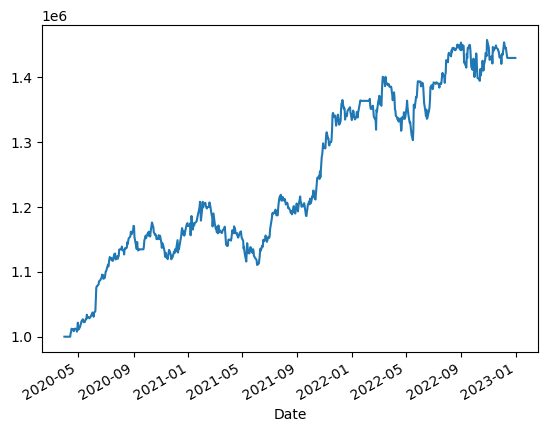

In [ ]:
return_port["Balance"].plot()

<Axes: xlabel='Date'>

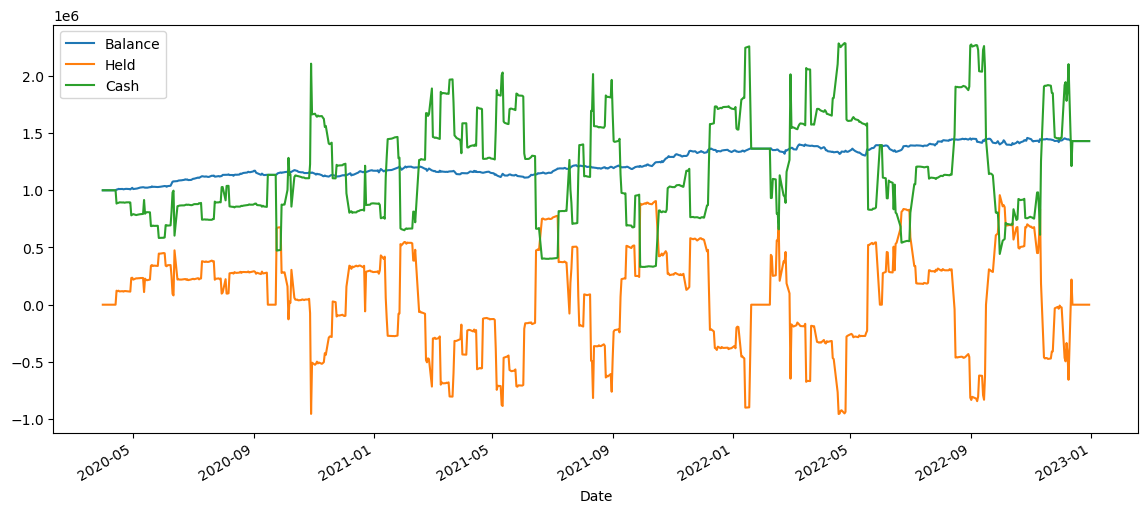

In [ ]:
return_port[["Balance", "Held" , "Cash"]].plot(figsize=(14,6))

<Axes: xlabel='Date'>

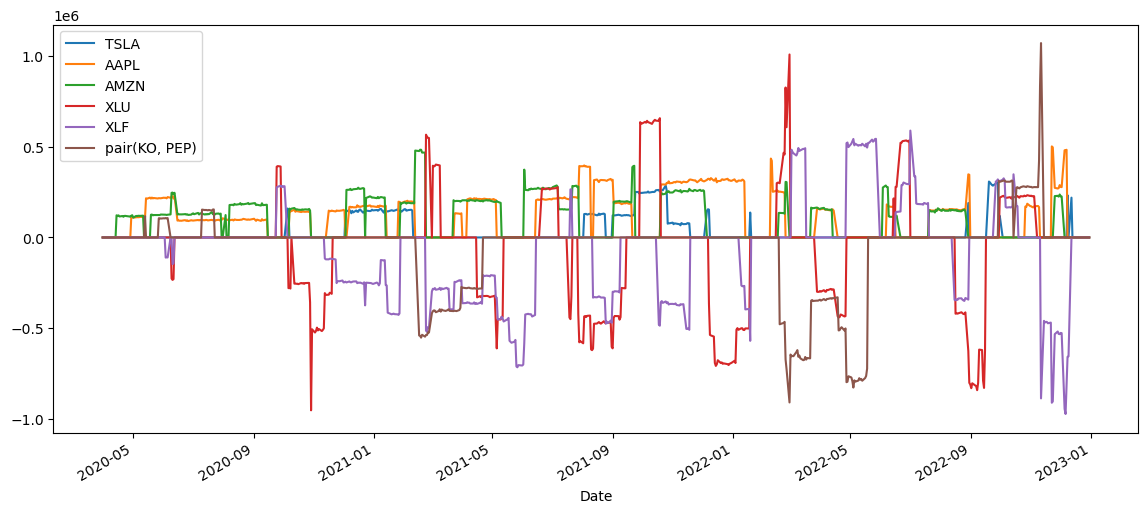

In [ ]:
held.plot(figsize=(14,6))

In [ ]:
#Metrics for the portfolio
from maximum_drawdown import maximumDrawdown
from ret import returnRate
from sharpe_ratio import sharpeRatio

sr = sharpeRatio(return_port["Balance"], rf)
annual_return, ret = returnRate(return_port["Balance"])
md, mdd = maximumDrawdown(return_port["Balance"])
max_transaction = return_port["Transaction"].max()
total_transaction = return_port["Transaction"].sum()


print(
    "Return: ", ret*100, "%"
    "\nAnnual Return: ", annual_return*100, "%"
    "\nSharpe Ratio: ", sr,
    "\nMaximum Drawdown: ", md*100, "%"
    "\nMaximum Drawdown Duration: ", mdd,
    "\nTotal Transaction Cost: ", total_transaction,
    "\nHighest Transaction Cost: ", max_transaction
)

Return:  43.0174604901494 %
Annual Return:  13.901576726749143 %
Sharpe Ratio:  1.007307 
Maximum Drawdown:  -8.06124736030246 %
Maximum Drawdown Duration:  121 
Total Transaction Cost:  65463.24589599813 
Highest Transaction Cost:  1547.695996408229
